# EX2


## Data Analysis using simple plots

- Review the examples of basic visualization using Python libraries and Pandas.

## Advertising data

Let's take a look at some data, ask some questions about that data, and then use linear regression to answer those questions!

A toy dataset for your exploratory data analysis:

./data/Advertising.csv

In [4]:
import pandas as pd
import numpy as np
import statistics

In [5]:
# read CSV file stored in the current directory and save the results
data = pd.read_csv('./data/Advertising.csv', skipinitialspace=True, index_col=0)

# display the first 5 rows
data.head()

,TV,Radio,Newspaper,Sales
3/11/19,230.1,37.8,69.2,22.1
3/12/19,44.5,39.3,45.1,10.4
3/13/19,17.2,45.9,69.3,9.3
3/14/19,151.5,41.3,58.5,18.5
3/15/19,180.8,10.8,58.4,12.9


What are the features?
- **TV:** advertising dollars spent on TV for a single product in a given market (in thousands of dollars)
- **Radio:** advertising dollars spent on Radio
- **Newspaper:** advertising dollars spent on Newspaper

What is the response?
- **Sales:** sales of a single product in a given market (in thousands of items)

What else do we know?
- Because the response variable is continuous, this is a **regression** problem.
- There are 200 **observations** (represented by the rows), and each observation is a single market.

In [6]:
#display all data. You can uncomment the code in the next line

#display(data)

data.shape

(200, 4)

## Part 1 Tasks

Create cells to solve each of the following problems.

(1) For each field of the data, what is the mean of the data? What is the median? Are there any dataset has mode value?

(2) For each field of the data, give the five-number summary, minimum, the first quartile (Q1), median, the third quartile (Q3), and maximum of the data.

(3) For each field of the data, visulize a boxplot of the data and compare it to your answer in (b).

(4) For Sales, visualize distribution of the data using histogram. Comment on the data’s modality (i.e., bimodal, trimodal, etc.)

(5) For Sales, visualize the trend of the data over time using a graph.

(6) For each pair (TV-Sales, Radio-Sales, Newspaper-Sales), calculate the Pearson's correlation coefficient factor r.

(7) For each pair (TV-Sales, Radio-Sales, Newspaper-Sales), visualize scatter graph.

(8) Discuss what the differences are between the three: (a) boxplot, (b) histogram, and (c) scatter plot with respect to founding.

In [7]:
# (1) For each field of the data, what is the mean of the data? What is the median? Are there any dataset has mode value?
# features: TV, Radio, Newspaper, Sales
TV_list = data['TV'].to_list()
Radio_list = data['Radio'].to_list()
Newspaper_list = data['Newspaper'].to_list()
Sales_list = data['Sales'].to_list()

def get_list_mean(list):
    return sum(list) / len(list)

def get_list_median(list):
    return np.median(list)

def get_list_mode(list):
    return statistics.mode(list)

print(f"TV mean: ", get_list_mean(TV_list), "\tMedian: ", get_list_median(TV_list), "\tMode: ", get_list_mode(TV_list))
print()
print(f"Radio mean: ", get_list_mean(Radio_list), "\tMedian: ", get_list_median(Radio_list), "\tMode: ", get_list_mode(Radio_list))
print()
print(f"Newspaper mean: ", get_list_mean(Newspaper_list), "\tMedian: ", get_list_median(Newspaper_list), "\tMode: ", get_list_mode(Newspaper_list))
print()
print(f"Sales mean: ", get_list_mean(Sales_list), "\tMedian: ", get_list_median(Sales_list), "\tMode: ", get_list_mode(Sales_list))

TV mean:  147.0425 	Median:  149.75 	Mode:  17.2

Radio mean:  23.264 	Median:  22.9 	Mode:  4.1

Newspaper mean:  30.554000000000002 	Median:  25.75 	Mode:  9.3

Sales mean:  14.0225 	Median:  12.9 	Mode:  9.7


In [8]:
# (2) For each field of the data, give the five-number summary,
# minimum, the first quartile (Q1), median, the third quartile (Q3), and maximum of the data.
def print_list_five_number_summary(list):
    minimum = np.min(list)
    q1 = np.percentile(list, 25)
    median = np.percentile(list, 50)
    q3 = np.percentile(list, 75)
    maximum = np.max(list)
    print(f"min: ", minimum, ", Q1: ", q1, ", median: ", median, ", q3: ", q3, ", max: ", maximum)

print("TV:")
print_list_five_number_summary(TV_list)
print("Radio:")
print_list_five_number_summary(Radio_list)
print("Newspaper:")
print_list_five_number_summary(Newspaper_list)
print("Sales:")
print_list_five_number_summary(Sales_list)


TV:
min:  0.7 , Q1:  74.375 , median:  149.75 , q3:  218.825 , max:  296.4
Radio:
min:  0.0 , Q1:  9.975 , median:  22.9 , q3:  36.525 , max:  49.6
Newspaper:
min:  0.3 , Q1:  12.75 , median:  25.75 , q3:  45.1 , max:  114.0
Sales:
min:  1.6 , Q1:  10.375 , median:  12.9 , q3:  17.4 , max:  27.0


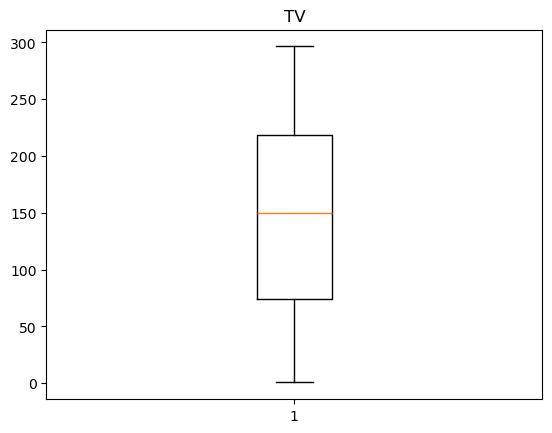

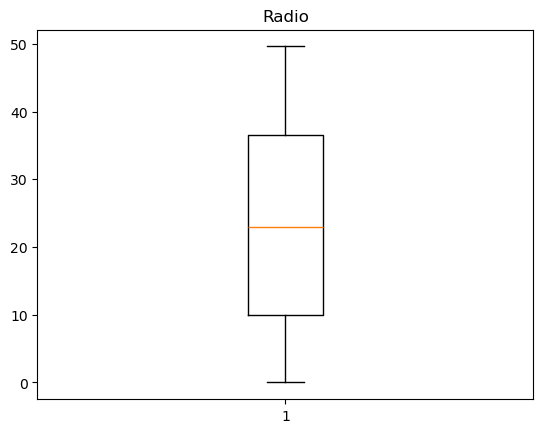

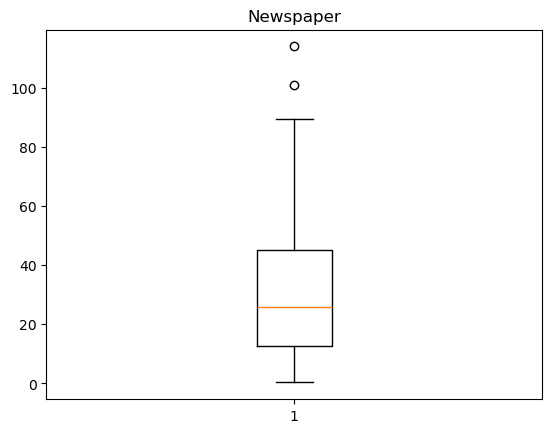

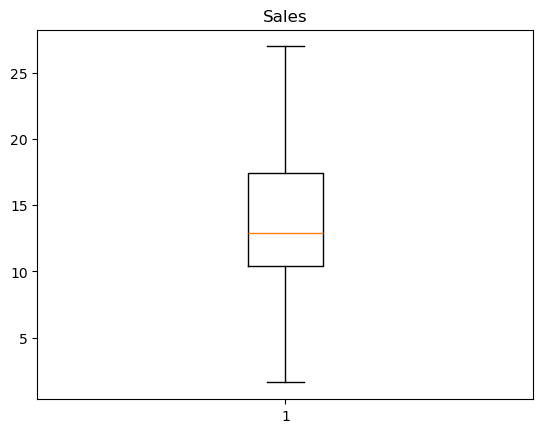

In [9]:
# (3) For each field of the data, visulize a boxplot of the data and compare it to your answer in (b).
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(TV_list)
plt.title("TV")

plt.figure()
plt.boxplot(Radio_list)
plt.title("Radio")

plt.figure()
plt.boxplot(Newspaper_list)
plt.title("Newspaper")

plt.figure()
plt.boxplot(Sales_list)
plt.title("Sales")

plt.show()

# In comparion with answers from b, (i guess this mean question 2). 
# All fields but 'Newspaper' has outliers, making a different max value.  

Text(0.5, 1.0, 'Histogram of Sales')

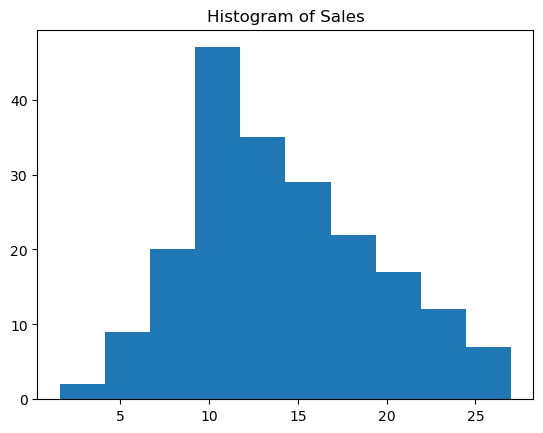

In [10]:
# (4) For Sales, visualize distribution of the data using histogram. Comment on the data’s modality (i.e., bimodal, trimodal, etc.).
plt.hist(Sales_list, bins=10)
plt.title("Histogram of Sales")

# the historgram of Sales shows me that sales peak at around 10 units of sales ranage
# the historgram shows as a unimodel distrubution

<function matplotlib.pyplot.show(close=None, block=None)>

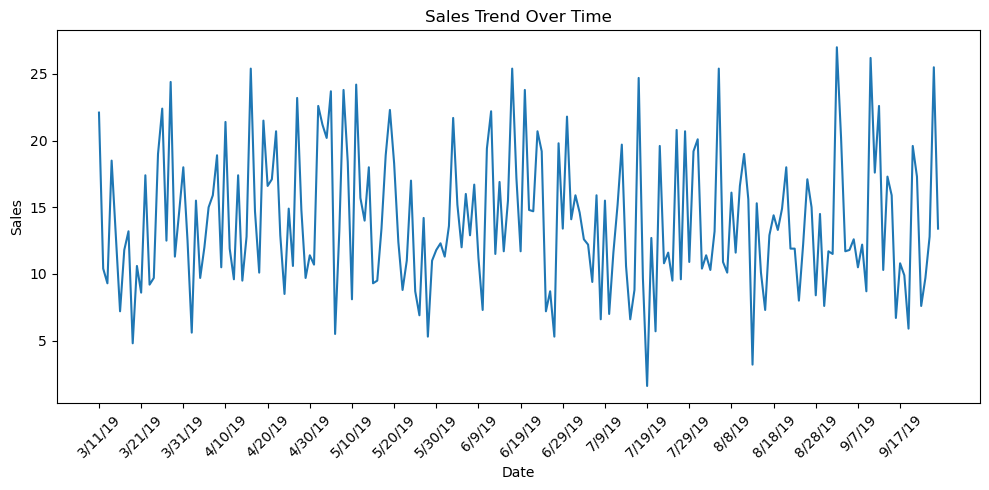

In [11]:
# (5) For Sales, visualize the trend of the data over time using a graph.

plt.figure(figsize=(10,5))
plt.plot(data.index, data['Sales'])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Trend Over Time")
plt.xticks(data.index[::10], rotation=45)
plt.tight_layout()
plt.show


In [12]:
# (6) For each pair (TV-Sales, Radio-Sales, Newspaper-Sales), calculate the Pearson's correlation coefficient factor r.
tv_sales = data["TV"].corr(data["Sales"])
radio_sales = data["Radio"].corr(data["Sales"])
newspaper_sales = data["Newspaper"].corr(data["Sales"])
print(f"TV vs Sales: ", tv_sales)
print(f"Radio vs Sales: ", radio_sales)
print(f"Newspaper vs Sales: ", newspaper_sales)

TV vs Sales:  0.7822244248616061
Radio vs Sales:  0.5762225745710551
Newspaper vs Sales:  0.22829902637616528


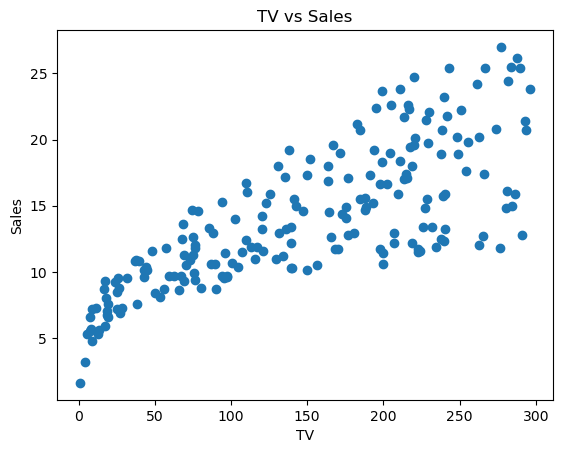

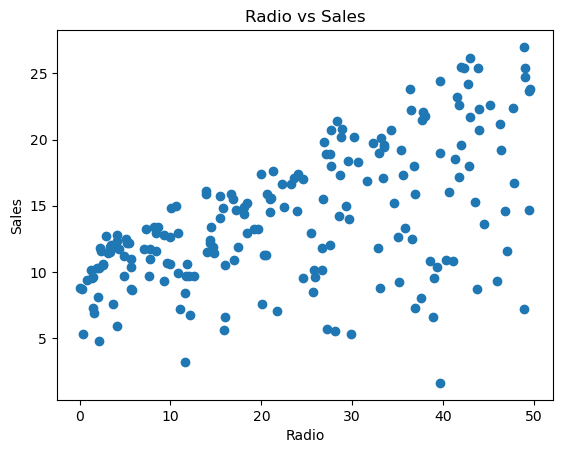

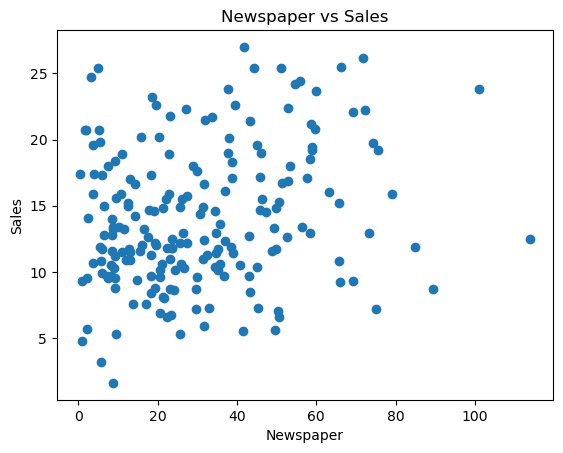

In [13]:
# (7) For each pair (TV-Sales, Radio-Sales, Newspaper-Sales), visualize scatter graph.
plt.figure()
plt.scatter(data["TV"], data["Sales"])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV vs Sales")

plt.figure()
plt.scatter(data["Radio"], data["Sales"])
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.title("Radio vs Sales")

plt.figure()
plt.scatter(data["Newspaper"], data["Sales"])
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")

plt.show()

#### (8) Discuss what the differences are between the three: (a) boxplot, (b) histogram, and (c) scatter plot with respect to founding.
with a historgram, one can find the distrubutions of a single list/feature of data, 
boxplots also only need a single list/feature as well and this allows one to get the spcific values like min, max, median etc... 
if we were to compare the sales historgram and boxplot, we can see the the min and max of the boxplot is the same as the historgram but also
that they also show the same peak levels too. 
with the scatter plot, this differs from the other two plots as this needs two list/features of data that correatlate to each other

## Part 2
It is good practice to write a summary of your findings from data anlaysis.

After doing data anlaysis, the data shows there is a clear strong corralation between sales and TV advertising, with increase in advertisment of TVs, sales also go up in turn. while increase of advertisments of Radio does have increase sales. its not as strong as TVs and newspaper advertisments have a very week corralation with sales as well

### Resources

#### Boxplot
https://towardsdatascience.com/understanding-boxplots-5e2df7bcbd51


- matplotlib.pyplot boxplot demo
https://matplotlib.org/3.1.1/gallery/pyplots/boxplot_demo_pyplot.html


#### matplotlib.pyplot
- scatter plot
https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.scatter.html


- histogram plot
https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.hist.html


#### pandas DataFrame
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html


- describe()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html


- corr()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html


- hist()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html


- plot.scatter()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.scatter.html


- pivot()
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html